# Notebook 13 — Bilateral (Two-Sided) Laplace Transform

F(s) = integral_{-inf}^{+inf} f(t) e^{-st} dt

Key insight: the same F(s) maps to DIFFERENT f(t) depending on the ROC strip.
Covered: numerical bilateral transform, ROC strips, causal vs anti-causal signals, non-causal filters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import warnings
warnings.filterwarnings('ignore')

class BilateralLaplace:
    'Numerical bilateral Laplace transform over all reals.'

    def __init__(self, t_lim=30.0, n_pts=6000):
        self.t_lim = t_lim
        self.n_pts = n_pts

    def forward(self, f, s):
        if not np.isscalar(s):
            return np.array([self.forward(f, sv) for sv in np.asarray(s).ravel()])

        def integrand(t):
            val = f(float(t))
            if not np.isscalar(val):
                val = float(np.mean(val))
            return float(np.real(val * np.exp(-s * t)))

        try:
            result, _ = quad(integrand, -self.t_lim, self.t_lim,
                             limit=500, epsabs=1e-8, epsrel=1e-8)
            return result
        except Exception:
            t_arr = np.linspace(-self.t_lim, self.t_lim, self.n_pts)
            y = np.array([integrand(tv) for tv in t_arr])
            return np.trapezoid(y, t_arr)

    def roc_check(self, f, sigma_range, n_sigma=50):
        sigmas = np.linspace(sigma_range[0], sigma_range[1], n_sigma)
        converges = []
        for sig in sigmas:
            try:
                val = self.forward(f, sig)
                converges.append(np.isfinite(val) and abs(val) < 1e10)
            except Exception:
                converges.append(False)
        return sigmas, np.array(converges)

bl = BilateralLaplace()
print('BilateralLaplace initialised (integration limits +/-30)')


BilateralLaplace initialised (integration limits +/-30)


f1=exp(-t)u(t):    F(0) = 1.0000  (analytic = 1.0)
f2=-exp(-t)u(-t):  F(0) = -10686474581523.4590  (diverges for Re(s)>-1)


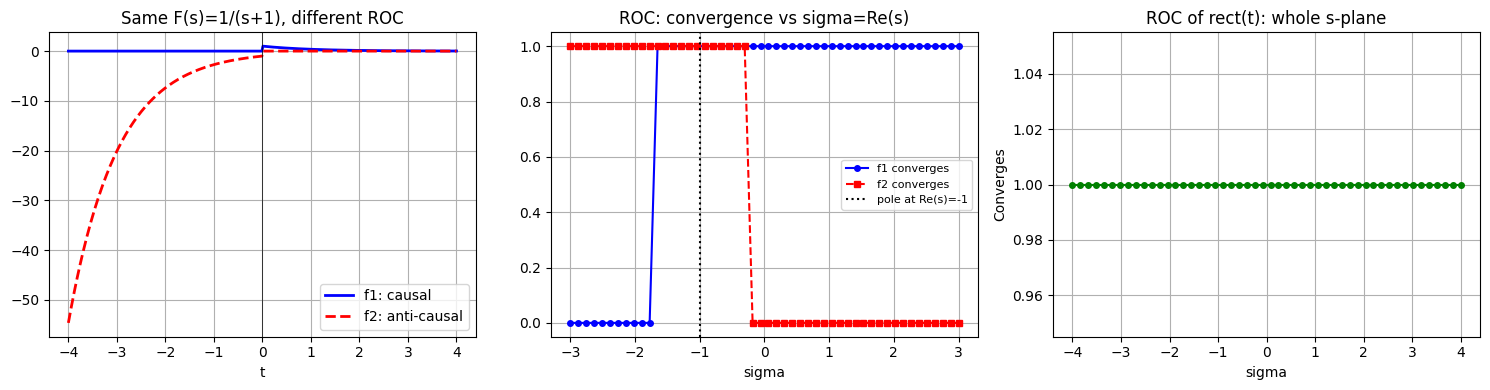

In [2]:
# The ROC Ambiguity: same F(s)=1/(s+1), different f(t)
# f1(t) = exp(-t)*u(t)   ROC: Re(s) > -1  (causal)
# f2(t) = -exp(-t)*u(-t) ROC: Re(s) < -1  (anti-causal)

def f_causal(t):     return np.exp(-t)  if t >= 0 else 0.0
def f_anticausal(t): return -np.exp(-t) if t <= 0 else 0.0

# Test at sigma=0 (inside ROC of f1, outside for f2)
F_c  = bl.forward(f_causal,     0.0)
F_ac = bl.forward(f_anticausal, 0.0)
print(f'f1=exp(-t)u(t):    F(0) = {F_c:.4f}  (analytic = 1.0)')
print(f'f2=-exp(-t)u(-t):  F(0) = {F_ac:.4f}  (diverges for Re(s)>-1)')

t_plot = np.linspace(-4, 4, 400)
f1_vals = np.array([f_causal(tv)     for tv in t_plot])
f2_vals = np.array([f_anticausal(tv) for tv in t_plot])
sigmas1, conv1 = bl.roc_check(f_causal,     (-3, 3))
sigmas2, conv2 = bl.roc_check(f_anticausal, (-3, 3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_plot, f1_vals, 'b-', lw=2, label='f1: causal')
axes[0].plot(t_plot, f2_vals, 'r--', lw=2, label='f2: anti-causal')
axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('Same F(s)=1/(s+1), different ROC')
axes[0].set_xlabel('t'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(sigmas1, conv1.astype(float), 'b-o', ms=4, label='f1 converges')
axes[1].plot(sigmas2, conv2.astype(float), 'r--s', ms=4, label='f2 converges')
axes[1].axvline(-1, color='k', ls=':', label='pole at Re(s)=-1')
axes[1].set_title('ROC: convergence vs sigma=Re(s)')
axes[1].set_xlabel('sigma'); axes[1].legend(fontsize=8); axes[1].grid(True)

def rect(t): return 1.0 if abs(t) <= 1 else 0.0
sigmas_r, conv_r = bl.roc_check(rect, (-4, 4))
axes[2].plot(sigmas_r, conv_r.astype(float), 'g-o', ms=4)
axes[2].set_title('ROC of rect(t): whole s-plane')
axes[2].set_xlabel('sigma'); axes[2].set_ylabel('Converges'); axes[2].grid(True)
plt.tight_layout(); plt.show()


In [3]:
# Two-sided signal: exp(-|t|) has analytic F(s)=2/(1-s^2) for -1<Re(s)<1
def f_twosided(t): return np.exp(-abs(t))

sigmas_ts, conv_ts = bl.roc_check(f_twosided, (-2.5, 2.5))

# Verify at sigma=0 (in ROC strip)
F_ts_num = bl.forward(f_twosided, 0.5)
F_ts_ana = 2.0 / (1 - 0.5**2)
print(f'exp(-|t|) at s=0.5: numerical={F_ts_num:.5f},  analytic={F_ts_ana:.5f}')

# Common bilateral pairs verification
pairs = [
    ('exp(-t)u(t)',     f_causal,     lambda s: 1/(s+1),    0.0),
    ('-exp(-t)u(-t)',   f_anticausal, lambda s: 1/(s+1),   -2.0),
    ('exp(-|t|)',       f_twosided,   lambda s: 2/(1-s**2), 0.0),
    ('rect(t/2)',       rect,         lambda s: 2*np.sinh(s)/s if abs(s)>1e-9 else 2.0, 0.5),
]

print()
print(f'{"f(t)":<20} {"Numerical":>12} {"Analytic":>12} {"ROC example"}')
print('-'*60)
for name, f_func, F_ana, sig in pairs:
    try:
        num = bl.forward(f_func, sig)
        ana = float(np.real(F_ana(sig)))
        print(f'{name:<20} {num:>12.5f} {ana:>12.5f}   sig={sig}')
    except Exception as ex:
        print(f'{name:<20} ERROR: {ex}')


exp(-|t|) at s=0.5: numerical=2.66667,  analytic=2.66667

f(t)                    Numerical     Analytic ROC example
------------------------------------------------------------
exp(-t)u(t)               1.00000      1.00000   sig=0.0
-exp(-t)u(-t)            -1.00000     -1.00000   sig=-2.0
exp(-|t|)                 2.00000      2.00000   sig=0.0
rect(t/2)                 2.08438      2.08438   sig=0.5


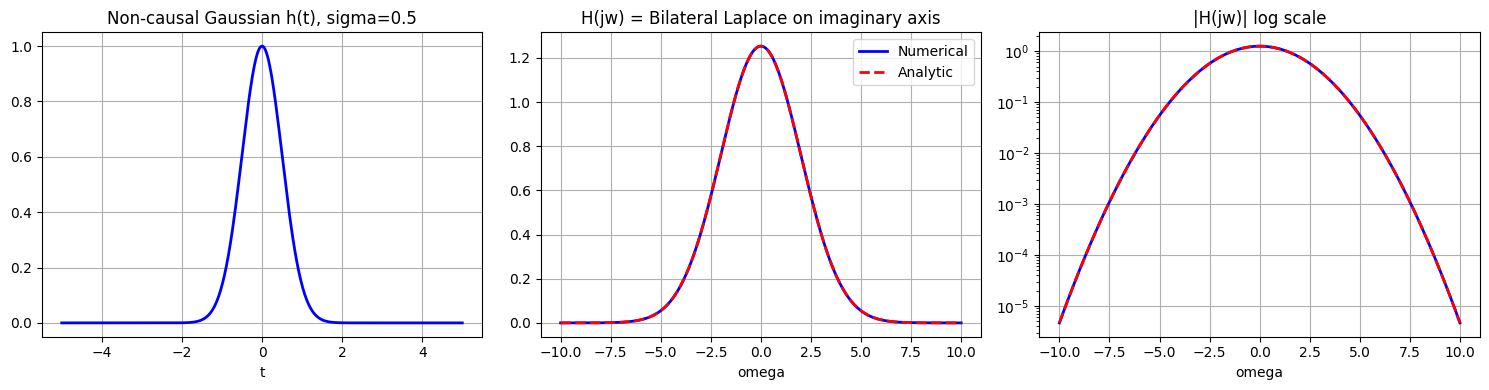

Max error (numerical vs analytic): 0.0000
Gaussian -> Gaussian: bilateral Laplace on jw-axis = Fourier Transform


In [4]:
# Non-causal (symmetric) Gaussian filter
# h(t)=exp(-t^2/(2*sigma^2)) is bilateral; its Fourier transform is also Gaussian
sigma_f = 0.5
def gauss(t): return np.exp(-t**2/(2*sigma_f**2))

# Evaluate on imaginary axis: F(jw) = Bilateral L{h}|_{s=jw} = Fourier transform
omega_arr = np.linspace(-10, 10, 300)
# Numerical (real part of bilateral transform at s=jw using small sigma offset)
H_num = np.array([bl.forward(gauss, 0.01 + 1j*w) for w in omega_arr])
# Analytic: sigma*sqrt(2pi)*exp(-sigma^2*w^2/2)
H_ana = sigma_f*np.sqrt(2*np.pi)*np.exp(-sigma_f**2*omega_arr**2/2)

t_plot2 = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_plot2, gauss(t_plot2), 'b-', lw=2)
axes[0].set_title(f'Non-causal Gaussian h(t), sigma={sigma_f}')
axes[0].set_xlabel('t'); axes[0].grid(True)

axes[1].plot(omega_arr, np.real(H_num), 'b-', lw=2, label='Numerical')
axes[1].plot(omega_arr, H_ana, 'r--', lw=2, label='Analytic')
axes[1].set_title('H(jw) = Bilateral Laplace on imaginary axis')
axes[1].set_xlabel('omega'); axes[1].legend(); axes[1].grid(True)

axes[2].semilogy(omega_arr, np.abs(H_num)+1e-12, 'b-', lw=2)
axes[2].semilogy(omega_arr, H_ana+1e-12, 'r--', lw=2)
axes[2].set_title('|H(jw)| log scale')
axes[2].set_xlabel('omega'); axes[2].grid(True)
plt.tight_layout(); plt.show()

print(f'Max error (numerical vs analytic): {np.max(np.abs(np.real(H_num)-H_ana)):.4f}')
print('Gaussian -> Gaussian: bilateral Laplace on jw-axis = Fourier Transform')


In [5]:
# Unilateral vs Bilateral comparison table
print('='*65)
print('UNILATERAL vs BILATERAL LAPLACE TRANSFORM')
print('='*65)
rows = [
    ('Integration range',  'x[0, +inf)',           'x(-inf, +inf)'),
    ('Handles ICs',        'Yes (natural)',         'No (need explicit)'),
    ('ROC shape',          'Half-plane Re(s)>sigma','Vertical strip sigma1<Re(s)<sigma2'),
    ('Same F(s) -> same f','Yes',                   'No: ROC determines f(t) uniquely'),
    ('Causal signals',     'Natural domain',        'Special case: ROC extends to +inf'),
    ('Anti-causal signals','Cannot represent',      'ROC extends to -inf'),
    ('Two-sided signals',  'Impossible',            'ROC is a finite strip'),
    ('Laplace<->Fourier',  'F(jw) if jw-axis in ROC','F(jw) = Fourier TF (if ROC includes jw)'),
    ('Primary use',        'Control, ODE solution', 'Signal theory, non-causal filters'),
]
print(f'  {"Property":<25} {"Unilateral":>18} {"Bilateral":>18}')
print('  ' + '-'*63)
for prop, uni, bi in rows:
    print(f'  {prop:<25} {uni:>18} {bi:>18}')


UNILATERAL vs BILATERAL LAPLACE TRANSFORM
  Property                          Unilateral          Bilateral
  ---------------------------------------------------------------
  Integration range                 x[0, +inf)      x(-inf, +inf)
  Handles ICs                    Yes (natural) No (need explicit)
  ROC shape                 Half-plane Re(s)>sigma Vertical strip sigma1<Re(s)<sigma2
  Same F(s) -> same f                      Yes No: ROC determines f(t) uniquely
  Causal signals                Natural domain Special case: ROC extends to +inf
  Anti-causal signals         Cannot represent ROC extends to -inf
  Two-sided signals                 Impossible ROC is a finite strip
  Laplace<->Fourier         F(jw) if jw-axis in ROC F(jw) = Fourier TF (if ROC includes jw)
  Primary use               Control, ODE solution Signal theory, non-causal filters
